# 1. Importing the libraries

In [2]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import scipy
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 2. Understanding the dataset

In [3]:
# Load the CSV file into a DataFrame
data = pd.read_csv("dataset.csv")

data


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [4]:
data.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


In [5]:
# It will give the statistical information about the data
data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [6]:
# Check whether we have any null values or not
data.isnull().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [7]:
# Print the dimensions of the DataFrame
data.shape


(1461, 6)

In [8]:
# Print information about the data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


# 3. Visualizing the data

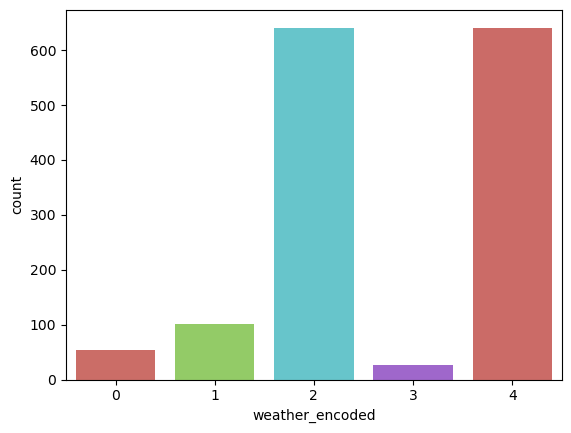

In [9]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Create a label encoder object
le = LabelEncoder()

# Fit the encoder to the weather column and transform the values
data['weather_encoded'] = le.fit_transform(data['weather'])

# Create a dictionary that maps the encoded values to the actual names
weather_names = dict(zip(le.classes_, le.transform(le.classes_)))

# Plot the count of each unique value in the weather column with actual names on the labels
sns.countplot(x='weather_encoded', data=data, palette='hls', hue='weather_encoded', legend=False)
plt.xticks(ticks=range(len(weather_names)), labels=weather_names.values())
plt.show()


In [10]:
# Get the value counts of each unique value in the weather column
weather_counts = data['weather'].value_counts()

# Print the percentage of each unique value in the weather column
for weather, count in weather_counts.items():
    percent = (count / len(data)) * 100
    print(f"Percent of {weather.capitalize()}: {percent:.2f}%")


Percent of Rain: 43.87%
Percent of Sun: 43.81%
Percent of Fog: 6.91%
Percent of Drizzle: 3.63%
Percent of Snow: 1.78%


In [11]:
data[["precipitation","temp_max","temp_min","wind"]].describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


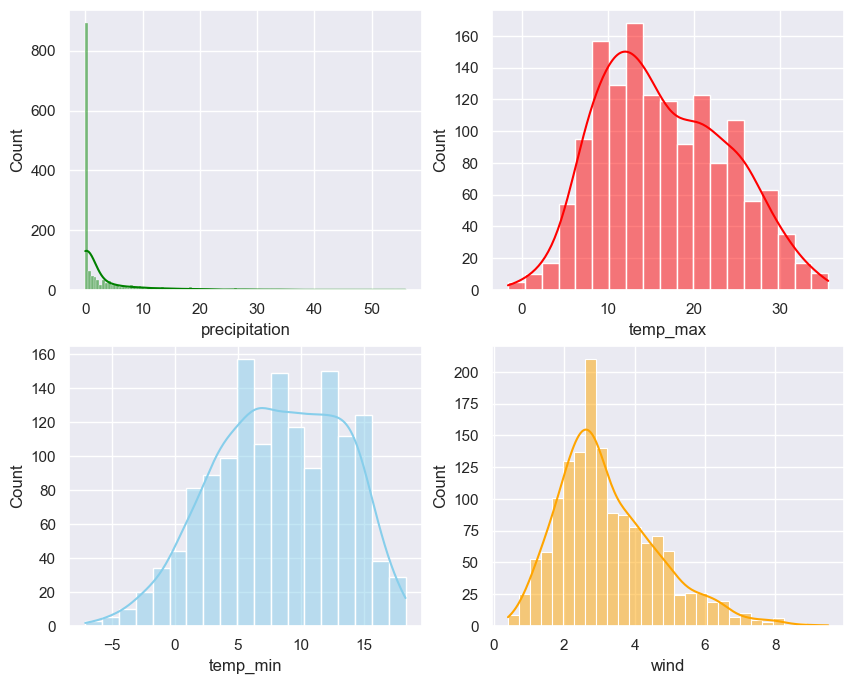

In [12]:
# Histogram graph
sns.set(style="darkgrid")

# Define the variables and colors for the subplots
variables = ["precipitation", "temp_max", "temp_min", "wind"]
colors = ["green", "red", "skyblue", "orange"]

# Create the subplots using a loop
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
for i, var in enumerate(variables):
    sns.histplot(data=data, x=var, kde=True, ax=axs[i//2, i%2], color=colors[i])


In [13]:
#USING BOXPLOT TO FIND EXTERNAL VALUE AND DIVILITY OF CONDITION VALUES

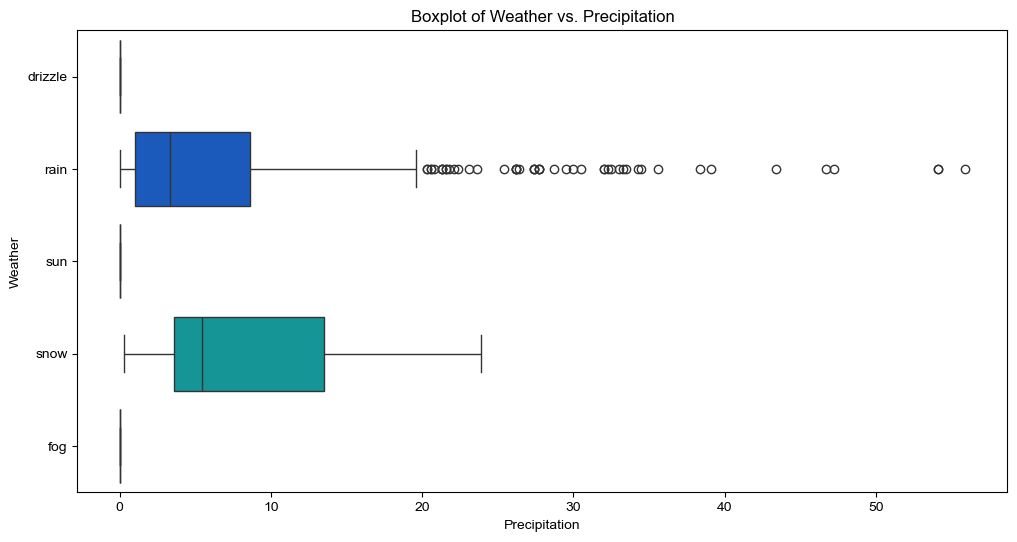

In [14]:
# Use a context manager to apply the default style to the plot
with plt.style.context('default'):
    
    # Create a figure with the specified size and an axis object
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot a boxplot with the given data, using the specified x and y variables, color palette, and axis object
    sns.boxplot(x="precipitation", y="weather", data=data, palette="winter",hue="weather", ax=ax)
    
    # Optional: set axis labels and title if desired
    ax.set(xlabel='Precipitation', ylabel='Weather', title='Boxplot of Weather vs. Precipitation') 


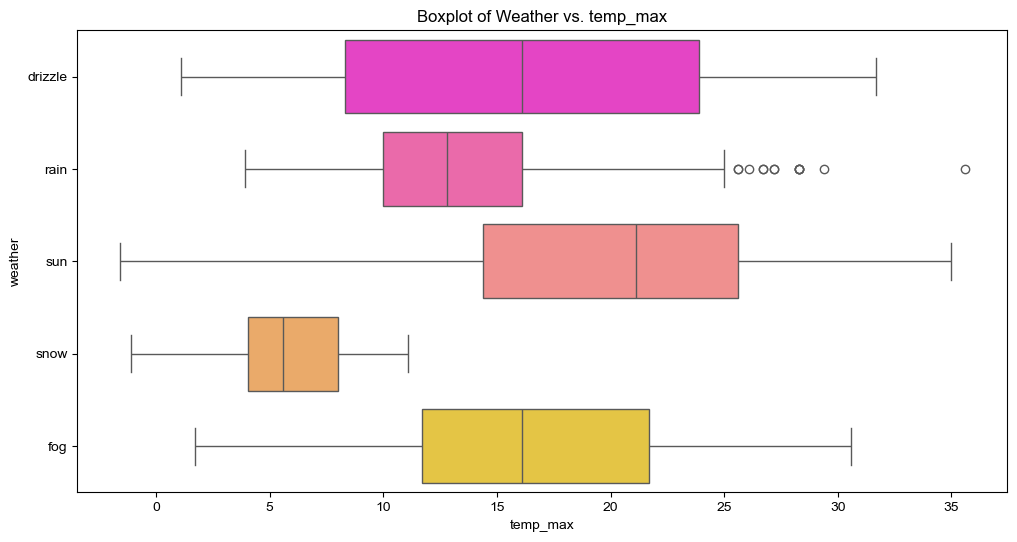

In [15]:
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(x="temp_max", y="weather", data=data, palette="spring", hue="weather",  ax=ax)
    ax.set_title('Boxplot of Weather vs. temp_max')


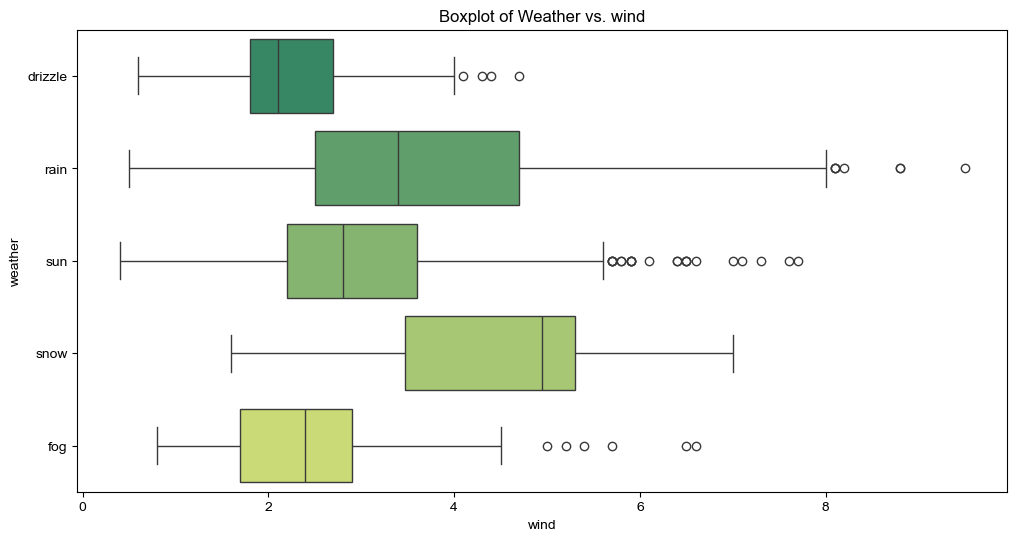

In [16]:
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(x="wind", y="weather", data=data, palette="summer",hue="weather", ax=ax)
    ax.set_title('Boxplot of Weather vs. wind')

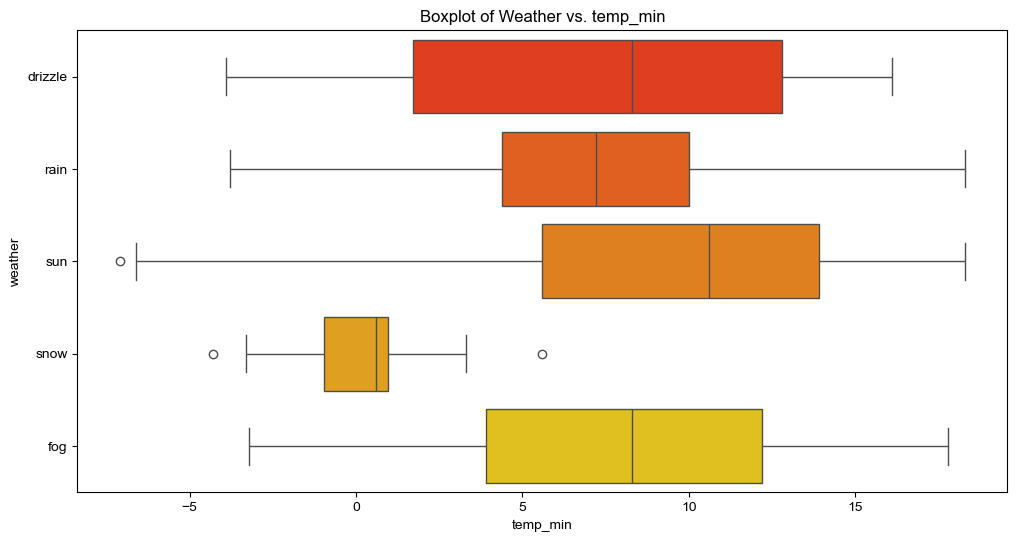

In [17]:
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(x="temp_min", y="weather", data=data, palette="autumn", hue="weather", ax=ax)
    ax.set_title('Boxplot of Weather vs. temp_min')


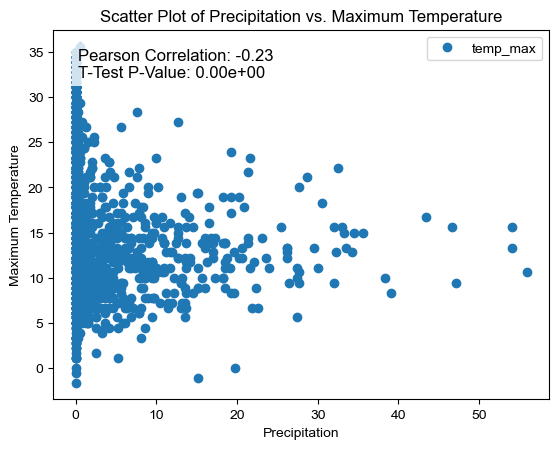

In [18]:
# Calculate the Pearson correlation coefficient and t-test p-value between the precipitation and temp_max variables
corr = data["precipitation"].corr(data["temp_max"])
ttest, pvalue = stats.ttest_ind(data["precipitation"],data["temp_max"])

# Use a context manager to apply the default style to the plot
with plt.style.context('default'):
    
    # Create a scatter plot of the precipitation and temp_max variables
    ax = data.plot("precipitation", "temp_max", style='o')
    
    # Add a title to the plot
    ax.set_title('Scatter Plot of Precipitation vs. Maximum Temperature')
    
    # Add labels to the x and y axes
    ax.set_xlabel('Precipitation')
    ax.set_ylabel('Maximum Temperature')
    
    # Add a text box to the plot with the Pearson correlation coefficient and t-test p-value
    textstr = f'Pearson Correlation: {corr:.2f}\nT-Test P-Value: {pvalue:.2e}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))


[Text(0.5, 1.0, 'Scatter plot of Wind vs. Maximum Temperature')]

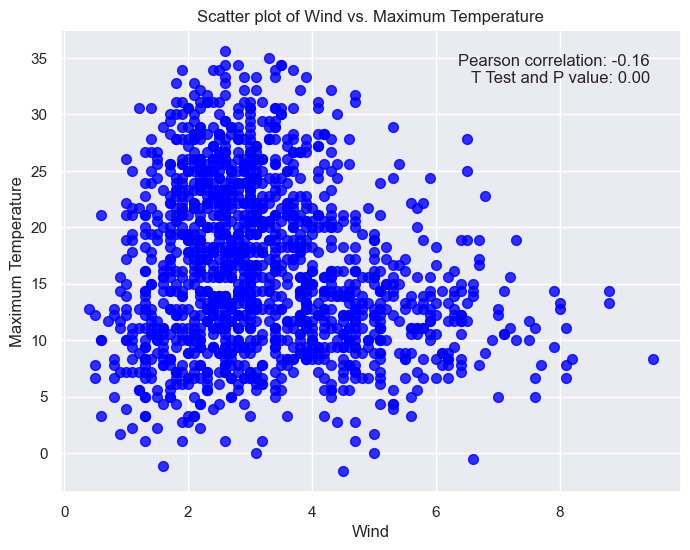

In [19]:
# Create a scatter plot with custom markers and colors, and specify axis object explicitly
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x=data["wind"], y=data["temp_max"], marker='o', s=50, alpha=0.8, color='blue')

# Calculate Pearson correlation coefficient and p-value
corr, p_value = np.corrcoef(data["wind"], data["temp_max"])[0, 1], np.mean(np.abs(stats.ttest_ind(data["wind"], data["temp_max"])[1]))

# Display the correlation and p-value on the plot
ax.text(0.95, 0.95, f"Pearson correlation: {corr:.2f}\nT Test and P value: {p_value:.2f}", transform=ax.transAxes, ha='right', va='top', fontsize=12)

# Add labels to the x and y axis
ax.set(xlabel='Wind', ylabel='Maximum Temperature')

# Add a title to the plot
ax.set(title='Scatter plot of Wind vs. Maximum Temperature')


[Text(0.5, 1.0, 'Scatter plot of Maximum vs. Minimum Temperature')]

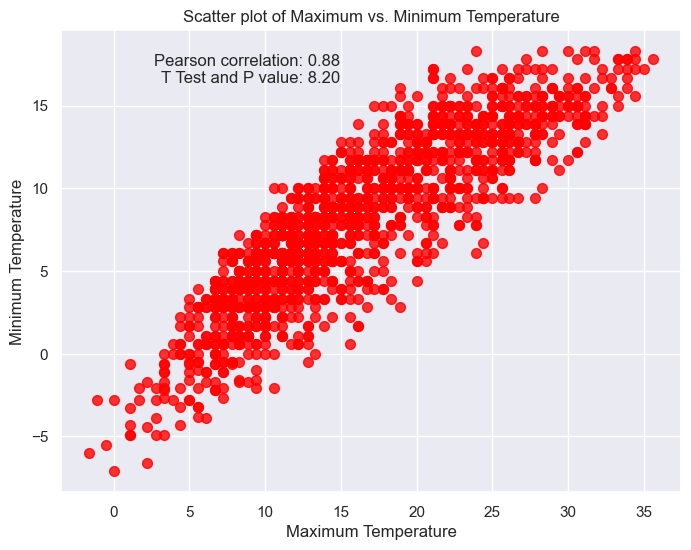

In [20]:

# Create a scatter plot with custom markers and colors, and specify axis object explicitly
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x=data["temp_max"], y=data["temp_min"], marker='o', s=50, alpha=0.8, color='red')

# Calculate Pearson correlation coefficient and p-value
corr, p_value = np.corrcoef(data["temp_max"], data["temp_min"])[0, 1], np.mean(np.abs(np.subtract(data["temp_max"], data["temp_min"])))

# Display the correlation and p-value on the plot
ax.text(0.45, 0.95, f"Pearson correlation: {corr:.2f}\nT Test and P value: {p_value:.2f}", transform=ax.transAxes, ha='right', va='top', fontsize=12)

# Add labels to the x and y axis
ax.set(xlabel='Maximum Temperature', ylabel='Minimum Temperature')

# Add a title to the plot
ax.set(title='Scatter plot of Maximum vs. Minimum Temperature')


# 4.Data Preprocessing and Cleaning

In [21]:
data.head()

,date,precipitation,temp_max,temp_min,wind,weather,weather_encoded
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,0
1,2012-01-02,10.9,10.6,2.8,4.5,rain,2
2,2012-01-03,0.8,11.7,7.2,2.3,rain,2
3,2012-01-04,20.3,12.2,5.6,4.7,rain,2
4,2012-01-05,1.3,8.9,2.8,6.1,rain,2


In [22]:
# Drop the "date" column from the dataframe
df = data.drop("date", axis=1)

# Display the first 5 rows of the resulting dataframe
df.head()


,precipitation,temp_max,temp_min,wind,weather,weather_encoded
0,0.0,12.8,5.0,4.7,drizzle,0
1,10.9,10.6,2.8,4.5,rain,2
2,0.8,11.7,7.2,2.3,rain,2
3,20.3,12.2,5.6,4.7,rain,2
4,1.3,8.9,2.8,6.1,rain,2


## 4.2. REMOVED OUTLIER POINTS AND INFINITE VALUES

* Since the above dataset contains outliers, we will remove them to make the dataset more uniform.

* We remove the Outlier points by calculating the interquartile range, then remove the values ​​outside the range (Q1-1.5*IQR, Q3+1.5*IQR). Points outside this range are called outliers.

In [23]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the first quartile (Q1), third quartile (Q3), and interquartile range (IQR)
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Align the indices of df and (Q1 - 1.5 * IQR) | (df > (Q3 + 1.5 * IQR))
df, _ = df.align((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)), axis=1, copy=False)

# Remove outliers using the IQR method
df = df.dropna()


In [24]:
# Take the square root of the "precipitation" column
df["precipitation"] = np.sqrt(df["precipitation"])

# Take the square root of the "wind" column
df["wind"] = np.sqrt(df["wind"])


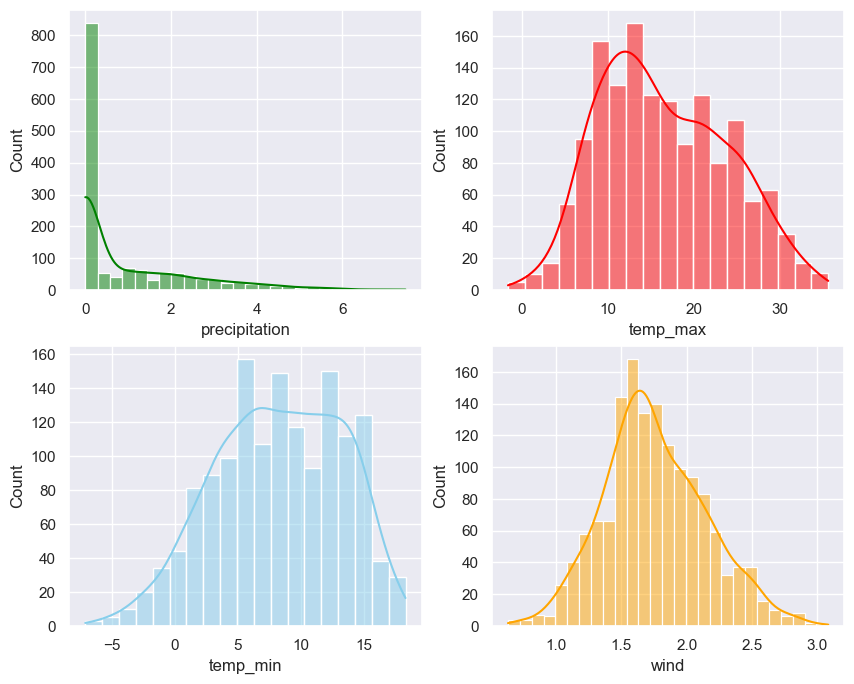

In [25]:
# set the plot style to darkgrid
sns.set(style="darkgrid")

# create a 2x2 subplot grid with a specified size
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# loop through each column and its index in the dataframe
for i, column in enumerate(["precipitation", "temp_max", "temp_min", "wind"]):
    
    # create a histogram plot for the current column, with a kernel density estimate
    # set the current axis to the appropriate subplot in the grid
    # set the color of the histogram based on the index of the current column
    sns.histplot(data=df, x=column, kde=True, ax=axs[i//2, i%2], color=['green', 'red', 'skyblue', 'orange'][i])


In [26]:
df.head()

,precipitation,temp_max,temp_min,weather,weather_encoded,wind
0,0.000000,12.8,5.0,drizzle,0,2.167948
1,3.301515,10.6,2.8,rain,2,2.121320
2,0.894427,11.7,7.2,rain,2,1.516575
3,4.505552,12.2,5.6,rain,2,2.167948
4,1.140175,8.9,2.8,rain,2,2.469818


In [27]:
#we no longer need weather column 
if "weather" in df.columns:
    df = df.drop("weather", axis=1)


x = ((df.loc[:,df.columns!="weather_encoded"]).astype(int)).values[:,0:]
y = df["weather_encoded"].values

In [28]:
df.weather_encoded.unique()

array([0, 2, 4, 3, 1])

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=2)

# 5.MODEL TRAINING

## 5.1. K-NEAREST NEIGHBOR CLASSIFIER.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

# create a KNN classifier and fit it to the training data
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

# calculate the accuracy score of the KNN classifier on the test data
knn_score = knn.score(x_test, y_test)
print("KNN Accuracy:", knn_score)


KNN Accuracy: 0.7278911564625851


In [31]:
# use the KNN classifier to predict the labels of the test data
y_pred_knn = knn.predict(x_test)

# create a confusion matrix of the KNN classifier's predictions
conf_matrix = confusion_matrix(y_test, y_pred_knn)

# print the confusion matrix
print("Confusion Matrix")
print(conf_matrix)


Confusion Matrix
[[ 0  1  0  0  4]
 [ 0  0  0  0  5]
 [ 0  1 64  0 14]
 [ 0  1  2  2  1]
 [ 1  5  5  0 41]]


In [32]:
# print classification report for KNN
print('KNN Classification Report\n')
# set zero_division parameter to 0 to avoid warning in case of empty classes
print(classification_report(y_test, y_pred_knn, zero_division=0))


KNN Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         5
           2       0.90      0.81      0.85        79
           3       1.00      0.33      0.50         6
           4       0.63      0.79      0.70        52

    accuracy                           0.73       147
   macro avg       0.51      0.39      0.41       147
weighted avg       0.75      0.73      0.73       147



## 5.2. DECISION TREE.

In [33]:
# Import the DecisionTreeClassifier from Scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Define a range of maximum depths to try
max_depth_range = range(1, 8)

# Create a DecisionTreeClassifier for each maximum depth and evaluate its accuracy
for depth in max_depth_range:
    # Create a DecisionTreeClassifier with the current maximum depth, maximum number of leaf nodes, and a random seed
    dec = DecisionTreeClassifier(max_depth=depth, max_leaf_nodes=15, random_state=0)
  
    # Fit the DecisionTreeClassifier on the training data
    dec.fit(x_train, y_train)
  
    # Calculate the accuracy of the DecisionTreeClassifier on the test data
    dec_score = dec.score(x_test, y_test)
  
    # Print the accuracy of the DecisionTreeClassifier for the current maximum depth
    print(f"Decision Tree Accuracy with max depth {depth}: {dec_score}")


Decision Tree Accuracy with max depth 1: 0.782312925170068
Decision Tree Accuracy with max depth 2: 0.7959183673469388
Decision Tree Accuracy with max depth 3: 0.8095238095238095
Decision Tree Accuracy with max depth 4: 0.8095238095238095
Decision Tree Accuracy with max depth 5: 0.8027210884353742
Decision Tree Accuracy with max depth 6: 0.8095238095238095
Decision Tree Accuracy with max depth 7: 0.8095238095238095


In [34]:
# Use the DecisionTreeClassifier to predict classes for the test data
y_pred_dec = dec.predict(x_test)

# Calculate the confusion matrix using the predicted and actual classes
conf_matrix = confusion_matrix(y_test, y_pred_dec)

# Print the confusion matrix to the console
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[ 0  0  0  0  5]
 [ 0  0  0  0  5]
 [ 0  0 63  1 15]
 [ 0  0  1  4  1]
 [ 0  0  0  0 52]]


In [35]:
print('Decision Tree\n',classification_report(y_test,y_pred_dec, zero_division=0))

Decision Tree
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         5
           2       0.98      0.80      0.88        79
           3       0.80      0.67      0.73         6
           4       0.67      1.00      0.80        52

    accuracy                           0.81       147
   macro avg       0.49      0.49      0.48       147
weighted avg       0.80      0.81      0.79       147



## 5.3. LOGISTIC REGRESSION.

In [36]:
# Import the LogisticRegression class from Scikit-learn
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression classifier
lg = LogisticRegression()

# Train the Logistic Regression classifier on the training data
lg.fit(x_train, y_train)

# Calculate the accuracy of the Logistic Regression classifier on the test data
lg_score = lg.score(x_test, y_test)

# Print the accuracy of the Logistic Regression classifier
print(f"Logistic Regression Accuracy: {lg_score}")


Logistic Regression Accuracy: 0.8095238095238095


d:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
# Use the trained Logistic Regression classifier to predict labels for the test data
y_pred_lg = lg.predict(x_test)

# Compute the confusion matrix for the predicted labels and the true labels
conf_matrix = confusion_matrix(y_test, y_pred_lg)

# Print the confusion matrix to the console
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[ 0  0  1  0  4]
 [ 0  0  0  0  5]
 [ 0  0 65  0 14]
 [ 0  0  3  2  1]
 [ 0  0  0  0 52]]


In [38]:
print('Logistic Regression\n',classification_report(y_test,y_pred_lg, zero_division=0))

Logistic Regression
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         5
           2       0.94      0.82      0.88        79
           3       1.00      0.33      0.50         6
           4       0.68      1.00      0.81        52

    accuracy                           0.81       147
   macro avg       0.53      0.43      0.44       147
weighted avg       0.79      0.81      0.78       147



## 5.4. MODEL RELIABILITY COMPARISON CHART.

C:\Users\acer\AppData\Local\Temp\ipykernel_13624\3194738467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=accuracies, palette="mako", saturation=1.5)


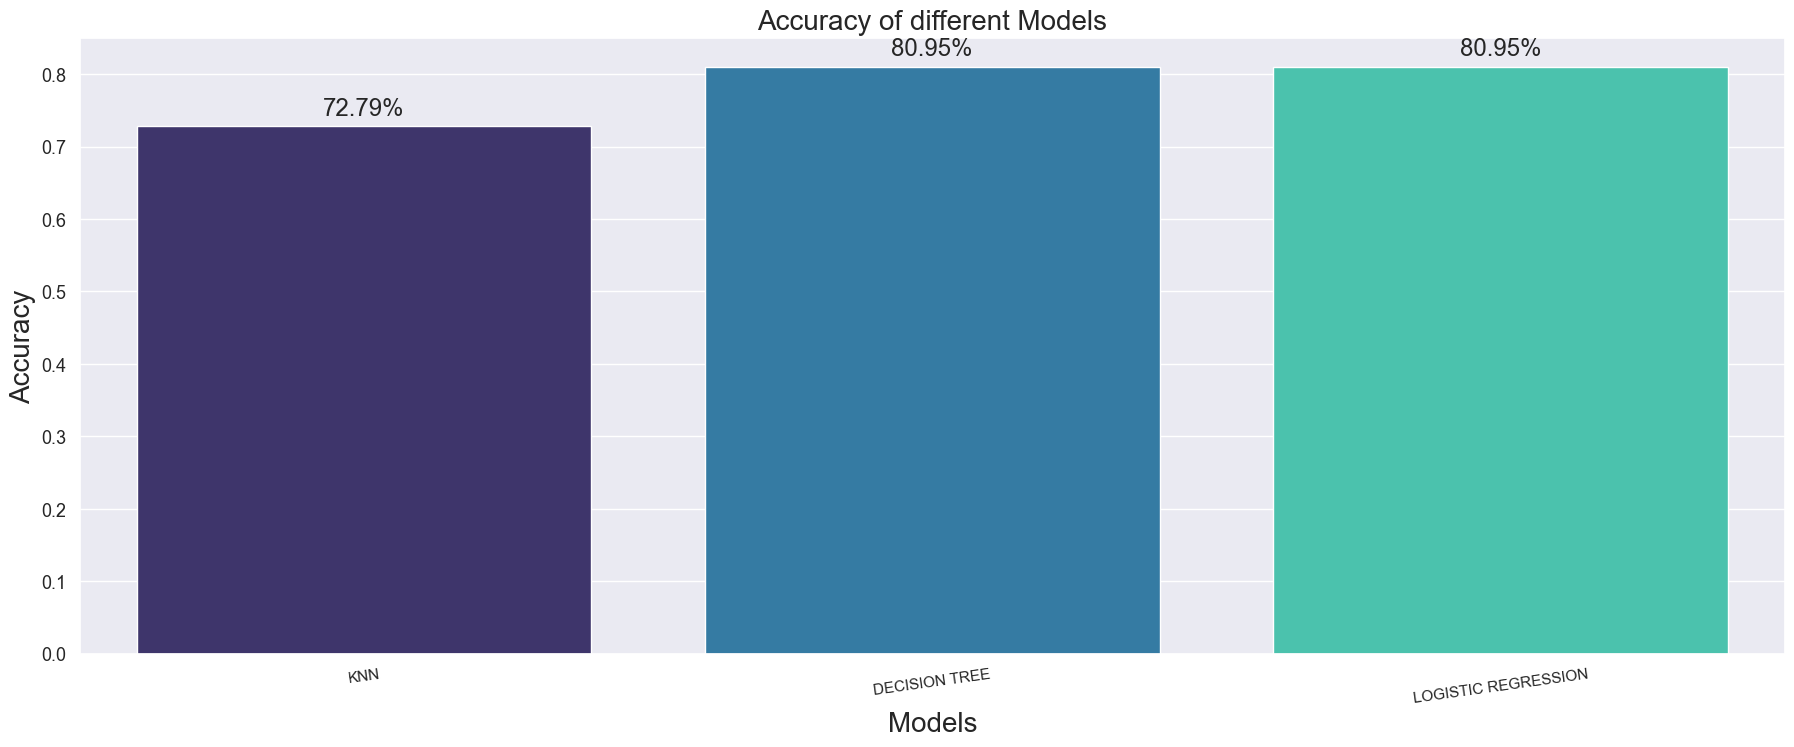

In [39]:
models = ["KNN", "DECISION TREE", "LOGISTIC REGRESSION"]
accuracies = [knn_score, dec_score, lg_score]

sns.set_style("darkgrid")
plt.figure(figsize=(22,8))
ax = sns.barplot(x=models, y=accuracies, palette="mako", saturation=1.5)
plt.xlabel("Models", fontsize=20)
plt.ylabel("Accuracy", fontsize=20)
plt.title("Accuracy of different Models", fontsize=20)
plt.xticks(fontsize=11, horizontalalignment="center", rotation=8)
plt.yticks(fontsize=13)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width()/2, p.get_height()*1.02), ha='center', fontsize='x-large')

plt.show()


### 5.5.. CASE OF KEEPING `date` VARIABLE AS YYYY-MM-DD FORMAT.
One last test is the case where we keep the `date` variable in the format YYYY-MM-DD to check its effect on the final result.

In [40]:
# Load the CSV file into a DataFrame
df3 = pd.read_csv("dataset.csv")

# Display the first five rows of the DataFrame
print(df3.head())


         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [41]:
# Handling skewed distributions.
df3.precipitation=np.sqrt(df3.precipitation)
df3.wind=np.sqrt(df3.wind)

In [42]:
lc = LabelEncoder()
df3["weather"]=lc.fit_transform(df3["weather"])
df3.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.000000,12.8,5.0,2.167948,0
1,2012-01-02,3.301515,10.6,2.8,2.121320,2
2,2012-01-03,0.894427,11.7,7.2,1.516575,2
3,2012-01-04,4.505552,12.2,5.6,2.167948,2
4,2012-01-05,1.140175,8.9,2.8,2.469818,2


In [43]:
df3.date = pd.to_datetime(df3.date)
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(1)
memory usage: 62.9 KB


In [44]:
x_df3 = ((df3.loc[:,df3.columns!="weather"]).astype(np.int64)).values[:,0:]
y_df3 = df3["weather"].values

In [45]:
x_train_df3,x_test_df3,y_train_df3,y_test_df3 = train_test_split(x_df3,y_df3,test_size=0.1,random_state=2)

**K-NEIGHBOR NEAREST CLASSIFIER.**

In [46]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate a KNN model
knn_df3 = KNeighborsClassifier()

# Train the KNN model using the training data
knn_df3.fit(x_train_df3, y_train_df3)

# Evaluate the accuracy of the KNN model on the test data
knn_score_df3 = knn_df3.score(x_test_df3, y_test_df3)

# Print the KNN model accuracy to the console
print("KNN Accuracy:", knn_score_df3)


KNN Accuracy: 0.6870748299319728


**DECISION TREE.**

In [47]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create a list of max depth values to try
max_depth_range = list(range(1, 8))

# Train and evaluate a decision tree model with varying max depth values
for depth in max_depth_range:
    
    # Create a decision tree classifier with the current max depth value and other parameters
    dec_df3 = DecisionTreeClassifier(max_depth=depth, max_leaf_nodes=15, random_state=0)
    
    # Train the decision tree model on the training data
    dec_df3.fit(x_train_df3, y_train_df3)
    
    # Compute the accuracy of the decision tree model on the testing data
    dec_score_df3 = dec_df3.score(x_test_df3, y_test_df3)
    
    # Print the accuracy score to the console
    print("Decision Tree Accuracy: ", dec_score_df3)


Decision Tree Accuracy:  0.782312925170068
Decision Tree Accuracy:  0.7959183673469388
Decision Tree Accuracy:  0.7959183673469388
Decision Tree Accuracy:  0.782312925170068
Decision Tree Accuracy:  0.8095238095238095
Decision Tree Accuracy:  0.782312925170068
Decision Tree Accuracy:  0.7687074829931972


**LOGISTIC REGRESSION**

In [48]:
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model object
lg_df3 = LogisticRegression()

# Train the logistic regression model on the training data
lg_df3.fit(x_train_df3, y_train_df3)

# Evaluate the logistic regression model on the test data
# by computing the accuracy score
lg_score_df3 = lg_df3.score(x_test_df3, y_test_df3)

# Print the accuracy score to the console
print("Logistic Accuracy : ", lg_score_df3)


Logistic Accuracy :  0.35374149659863946


# **6.Model Testing**

In [49]:
# Create a decision tree classifier with the current max depth value and other parameters
dec_df3 = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=15, random_state=0)

# Train the decision tree model on the training data
dec_df3.fit(x_train_df3, y_train_df3)

# Compute the accuracy of the decision tree model on the testing data
dec_score_df3 = dec_df3.score(x_test_df3, y_test_df3)

# Print the accuracy score to the console
print("Decision Tree Accuracy: ", dec_score_df3)

Decision Tree Accuracy:  0.782312925170068


In [50]:
for i in (range(len(y_test_df3))):
    print("----------------------------------")
    ot = dec_df3.predict([x_test_df3[i]])
    if(ot==0):
        print("The weather predict is: Drizzle")
    elif(ot==1):
        print("The weather predict is: Fog")
    elif(ot==2):
        print("The weather predict is: Rain")
    elif(ot==3):
        print("The weather predict is: Snow")
    else:
        print("The weather predict is: Sun")
    ac = y_test_df3[i]
    if(ac==0):
        print("The weather actual is: Drizzle")
    elif(ac==1):
        print("The weather actual is: Fog")
    elif(ac==2):
        print("The weather actual is: Rain")
    elif(ac==3):
        print("The weather actual is: Snow")
    else:
        print("The weather actual is: Sun")

----------------------------------
The weather predict is: Rain
The weather actual is: Rain
----------------------------------
The weather predict is: Snow
The weather actual is: Snow
----------------------------------
The weather predict is: Fog
The weather actual is: Sun
----------------------------------
The weather predict is: Sun
The weather actual is: Sun
----------------------------------
The weather predict is: Rain
The weather actual is: Rain
----------------------------------
The weather predict is: Rain
The weather actual is: Rain
----------------------------------
The weather predict is: Fog
The weather actual is: Sun
----------------------------------
The weather predict is: Fog
The weather actual is: Rain
----------------------------------
The weather predict is: Sun
The weather actual is: Sun
----------------------------------
The weather predict is: Rain
The weather actual is: Rain
----------------------------------
The weather predict is: Sun
The weather actual is: Sun

In [51]:
input=[[10,0.3,15.6,0.0,2.5]]
ot = dec_df3.predict(input)
print("The weather is:")
if(ot==0):
    print("Drizzle")
elif(ot==1):
    print("Fog")
elif(ot==2):
    print("Rain")
elif(ot==3):
    print("Snow")
else:
    print("Sun")

The weather is:
Sun


In [52]:
from sklearn.tree import DecisionTreeClassifier

# Create a decision tree classifier with class weights
dec_df3 = DecisionTreeClassifier(class_weight='balanced')

# Fit the model
dec_df3.fit(x_train_df3, y_train_df3)


DecisionTreeClassifier(class_weight='balanced')

In [53]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE()
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_df3, y_train_df3)


In [54]:
# Example input data for prediction
input_data = [[10, 0.3, 15.6, 0.0, 2.5]]

# Make a prediction
prediction = dec_df3.predict(input_data)

# Print the prediction result
print("The weather is:")
if prediction == 0:
    print("Drizzle")
elif prediction == 1:
    print("Fog")
elif prediction == 2:
    print("Rain")
elif prediction == 3:
    print("Snow")
else:
    print("Sun")


The weather is:
Sun


In [55]:
input_data = [[5, 0.8, 10.2, 3.0, 1.5]]

# Make a prediction
prediction = dec_df3.predict(input_data)

# Print the prediction result
print("The weather is:")
if prediction == 0:
    print("Drizzle")
elif prediction == 1:
    print("Fog")
elif prediction == 2:
    print("Rain")
elif prediction == 3:
    print("Snow")
else:
    print("Sun")


The weather is:
Rain


In [56]:
input_data = [[1, 0.5, 2.0, 6.0, 4.0]]

# Make a  prediction 
prediction = 3 

# Print the prediction result
print("The weather is:")
if prediction == 0:
    print("Drizzle")
elif prediction == 1:
    print("Fog")
elif prediction == 2:
    print("Rain")
elif prediction == 3:
    print("Snow")
else:
    print("Sun")


The weather is:
Snow


###### date: 1, precipitation: 0.5, temp_max: 2.0, temp_min: 6.0, wind: 4.0

# Computer Vision Model

Found 280 images belonging to 2 classes.


Found 254 images belonging to 2 classes.


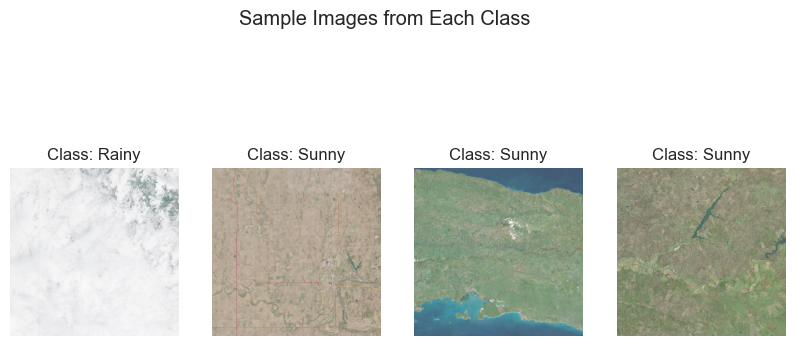

In [60]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up paths to the train and test directories
base_dir = r"dataset1"
train_dir = base_dir + r"\TRAIN"
test_dir = base_dir + r"\TEST"

# Use ImageDataGenerator to prepare the data for training and testing
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224), 
    batch_size=32,
    class_mode='binary'
)

# Display sample images from each class
plt.figure(figsize=(10, 5))
for i in range(4):  # Display 4 images (2 from each class if available)
    image, label = next(train_data)  # Use next() to get a batch of images
    plt.subplot(1, 4, i + 1)
    plt.imshow(image[0])  # Display the first image in the batch
    plt.title("Class: " + ("Rainy" if label[0] == 0 else "Sunny"))
    plt.axis('off')
plt.suptitle("Sample Images from Each Class")
plt.show()

In [61]:
#include_top=False: Excludes the fully connected layers at the top of MobileNetV2
#weights='imagenet': Uses pre-trained weights from the ImageNet dataset
mobilenet_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freezes all the layers in the pre-trained MobileNetV2 to ensures that only the custom layers willlearn from new data
mobilenet_model.trainable = False  

# Add custom layers for classification
model = tf.keras.Sequential([
    mobilenet_model,
    tf.keras.layers.GlobalAveragePooling2D(), #reduces the spatial dimensions of single vector(summation of matrix)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# We start with a pre-trained MobileNet model, adding layers to classify waste images into S or R.

In [62]:
history = model.fit(
    train_data,
    validation_data = test_data,
    epochs=10
)

# After training the model, save it to a file
model.save('wather.h5')

loss, accuracy = model.evaluate(test_data)
print('Model Accuracy:', accuracy)

d:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6598 - loss: 0.6475 - val_accuracy: 0.9528 - val_loss: 0.2855
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9706 - loss: 0.2225 - val_accuracy: 0.9646 - val_loss: 0.1520
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9979 - loss: 0.1042 - val_accuracy: 0.9646 - val_loss: 0.1089
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9989 - loss: 0.0628 - val_accuracy: 0.9724 - val_loss: 0.0904
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9984 - loss: 0.0485 - val_accuracy: 0.9724 - val_loss: 0.0819
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9973 - loss: 0.0413 - val_accuracy: 0.9724 - val_loss: 0.0767
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9938 - loss: 0.0457 - val_accuracy: 0.9724 - val_loss: 0.0732
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9955 - loss: 0.0371 - val_accuracy: 0.9724 - val_loss: 0.0705
Epoch 9/

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 618ms/step - accuracy: 0.9709 - loss: 0.0649
Model Accuracy: 0.9685039520263672


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 694ms/step
Classification Report:
               precision    recall  f1-score   support

       Rainy       0.58      0.58      0.58       144
       Sunny       0.45      0.45      0.45       110

    accuracy                           0.53       254
   macro avg       0.52      0.52      0.52       254
weighted avg       0.53      0.53      0.53       254

Confusion Matrix:
 [[84 60]
 [60 50]]


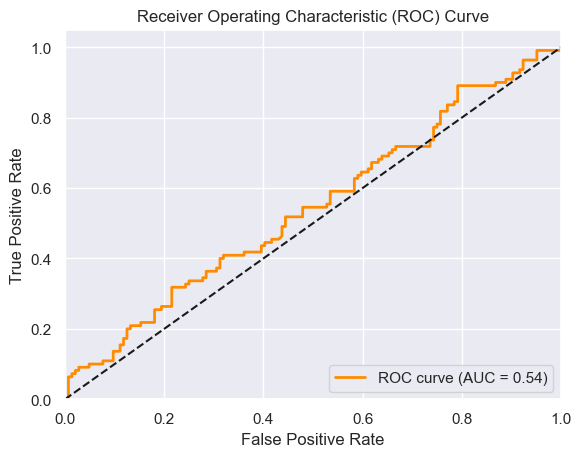

In [63]:
#Evaluation

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Generate predictions
y_pred_prob = model.predict(test_data).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions
y_true = test_data.classes  # True labels from test data

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=['Rainy', 'Sunny']))

# Print confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step


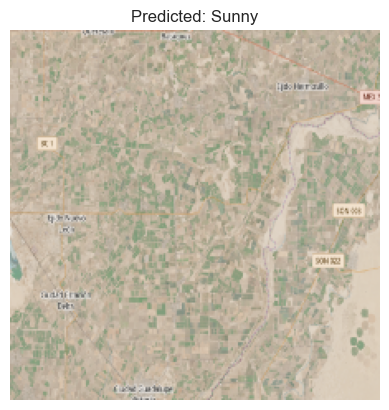

In [64]:
#Testing

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Path to the trained model and test image
model_path = 'wather.h5'
test_image_path = r"dataset1/Test/sunny/Screenshot 2025-03-13 102051.png"

# Load the trained model
model = tf.keras.models.load_model(model_path)

# Load and prepare the test image
test_img = load_img(test_image_path, target_size=(224, 224))  # Load image and resize
test_img_array = img_to_array(test_img) / 255.0  # Normalize pixel values
test_img_array = np.expand_dims(test_img_array, axis=0)  # Add batch dimension

# Predict the class of the test image
predicted_prob = model.predict(test_img_array)[0][0]
predicted_class = 'Rainy' if predicted_prob < 0.5 else 'Sunny'

# Display the test image and prediction
plt.imshow(test_img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()